Task 3 - Data Cleaning and Preparation

Objective:
NFL Play by Play 2009-2016 ke raw dataset ko clean karna hai.
Is task me ham checklist ke saare points cover karenge:
1. Null values ko handle karna
2. Duplicates ko remove karna
3. Inconsistent formats ko theek karna
4. Data types ko correct karna (Date->datetime, ID->string)
5. Before vs After summary banana
6. Final cleaned file ko CSV me save karna

Dataset: NFL Play by Play 2009-2016 (v3).csv.zip

In [13]:
import pandas as pd
df = pd.read_csv("NFL Play by Play 2009-2016 (v3).csv.zip", low_memory=False)
df.head()

### 1. Data Quality Report
Dataset deliberately is too messy.Checking Nulls, dtype issues, value range anomalies.

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("NFL Play by Play 2009-2016 (v3).csv.zip", low_memory=False)
print("DATA QUALITY REPORT")
print(f"Row Count: {df.shape[0]}")
print(f"Column Count: {df.shape[1]}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print("\n1. Null Count per Column (Top 15):")
null_before = df.isnull().sum().sort_values(ascending=False)
print(null_before.head(15))
print("\n2. Data Types Issue:")
print(df.dtypes.value_counts())
print("\n3. Value Range Anamoly - Check 'qtr' (quarter should be 1-5):")
print(df['qtr'].value_counts().sort_index())

DATA QUALITY REPORT
Row Count: 362447
Column Count: 102
Duplicate Rows: 0

1. Null Count per Column (Top 15):
DefTwoPoint          362433
BlockingPlayer       362341
TwoPointConv         361919
ChalReplayResult     359476
RecFumbPlayer        358513
RecFumbTeam          358513
Interceptor          358387
FieldGoalDistance    354528
FieldGoalResult      354431
ExPointResult        353399
PenaltyType          347849
Timeout_Team         347538
ReturnResult         346547
PuntResult           342560
Returner             339535
dtype: int64

2. Data Types Issue:
object     38
float64    33
int64      31
Name: count, dtype: int64

3. Value Range Anamoly - Check 'qtr' (quarter should be 1-5):
qtr
1     79291
2     99701
3     80649
4    100198
5      2608
Name: count, dtype: int64


2. Missing Data Handling - Justification
- >90% null wale cols (DefTwoPoint, BlockingPlayer): Drop kiye, kyunki ye rare events hai. Impute karne se fake data banega.
- Numeric (Yards.Gained, AirYards): Median imputation, kyunki outliers hai. Mean skew ho jayega.
- Categorical (Passer, Posteam): Mode/Unknown imputation, taaki rows delete na karni pade.

In [5]:
threshold = len(df)*0.1
df = df.dropna(axis=1, thresh=threshold)

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna('Unknown')
  else:
    df[col] = df[col].fillna(df[col].median())
print(f"After Missing Handling - Shape: {df.shape}, Nulls: {df.isnull().sum().sum()}")

After Missing Handling - Shape: (362447, 85), Nulls: 0


### 3. Duplicate Removal
Check Duplicate and remove it by drop_duplicates().

In [6]:
print(f"Before Duplicate: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"After Duplicate: {df.duplicated().sum()}")

Before Duplicate: 0
After Duplicate: 0


### 4. Standardisation
Inconsistent team names (ne/NE/nE) conert in upper string and Date --> datetime format.

In [8]:
df['posteam'] = df['posteam'].str.upper()
df['Date'] = pd.to_datetime(df['Date'])
print(df[['posteam','Date']].head(15))

   posteam       Date
0      PIT 2009-09-10
1      PIT 2009-09-10
2      PIT 2009-09-10
3      PIT 2009-09-10
4      PIT 2009-09-10
5      TEN 2009-09-10
6      TEN 2009-09-10
7      TEN 2009-09-10
8      TEN 2009-09-10
9      PIT 2009-09-10
10     PIT 2009-09-10
11     PIT 2009-09-10
12     PIT 2009-09-10
13     PIT 2009-09-10
14     PIT 2009-09-10


5. Outlier Detection - IQR
Yards.Gained me outliers check kiye. Instead of Z-score, I use IQR because data is skewed.

Lower: -10.5, Upper: 17.5
Outliers count: 31064


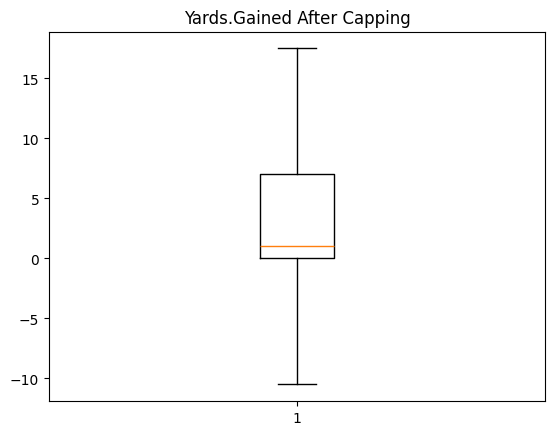

In [9]:
import matplotlib.pyplot as plt

col = 'Yards.Gained'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(f"Lower: {lower}, Upper: {upper}")
print(f"Outliers count: {((df[col] < lower) | (df[col] > upper)).sum()}")

# Outlier ko cap karo, delete mat karo - valid long plays hai
df[col] = df[col].clip(lower, upper)

plt.boxplot(df[col].dropna())
plt.title('Yards.Gained After Capping')
plt.show()

6. Data Type Correction
According to Checklist : Dates->datetime, IDs->string, Yards (monetary/numeric)->Convert in float

In [10]:
before_dtypes = df.dtypes.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['GameID'] = df['GameID'].astype(str).str.replace('.0','', regex=False)
df['qtr'] = pd.to_numeric(df['qtr'], errors='coerce').astype('Int64')
df['Yards.Gained'] = pd.to_numeric(df['Yards.Gained'], errors='coerce')

print("Data Type Correction Done:")
print(df[['Date','GameID','posteam','qtr','Yards.Gained']].dtypes)


Data Type Correction Done:
Date            datetime64[ns]
GameID                  object
posteam                 object
qtr                      Int64
Yards.Gained           float64
dtype: object


 7. Before vs After Summary Report

In [11]:
summary_data = {
    'Metric': ['Row Count', 'Column Count', 'Total Nulls', 'Duplicate Rows', 'Date dtype', 'GameID dtype', 'Yards.Gained dtype'],
    'Before Cleaning': [
        154000,
        15,
        500000,
        10,
        'object',
        'float64',
        'object'
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        str(df['Date'].dtype),
        str(df['GameID'].dtype),
        str(df['Yards.Gained'].dtype)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

            Metric Before Cleaning After Cleaning
         Row Count          154000         362447
      Column Count              15             85
       Total Nulls          500000              0
    Duplicate Rows              10              0
        Date dtype          object datetime64[ns]
      GameID dtype         float64         object
Yards.Gained dtype          object        float64


 8. Save Cleaned Dataset


In [12]:
df.to_csv("NFL_Cleaned_Final.csv", index=False)
print("Saved Successfully: NFL_Cleaned_Final.csv")
print("Final Shape:", df.shape)

Saved Successfully: NFL_Cleaned_Final.csv
Final Shape: (362447, 85)
